In [ ]:
yimport geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

In [ ]:
stations = gpd.read_file("/Users/kunjalbhatta/Desktop/capstone data/underground/Underground_Stations/Underground_Stations.shp")

In [ ]:
print("Columns:", stations.columns.tolist())
print("CRS:", stations.crs)
print(stations.head(3))

Columns: ['OBJECTID', 'NAME', 'LINES', 'ATCOCODE', 'MODES', 'ACCESSIBIL', 'NIGHT_TUBE', 'NETWORK', 'DATASET_LA', 'FULL_NAME', 'geometry']
CRS: EPSG:27700
   OBJECTID           NAME                                  LINES  \
0       111     St. Paul's                                Central   
1       112       Mile End  District, Hammersmith & City, Central   
2       113  Bethnal Green                                Central   

      ATCOCODE      MODES                               ACCESSIBIL NIGHT_TUBE  \
0  940GZZLUSPU  bus, tube                           Not Accessible        Yes   
1  940GZZLUMED  bus, tube  Partially Accessible - Interchange Only        Yes   
2  940GZZLUBLG  bus, tube                           Not Accessible        Yes   

              NETWORK DATASET_LA              FULL_NAME  \
0  London Underground 2021-11-29     St. Paul's station   
1  London Underground 2021-11-29       Mile End station   
2  London Underground 2021-11-29  Bethnal Green station   

       

In [ ]:
stations = stations.to_crs(epsg=4326)

Text(930.756313131313, 0.5, 'Latitude')

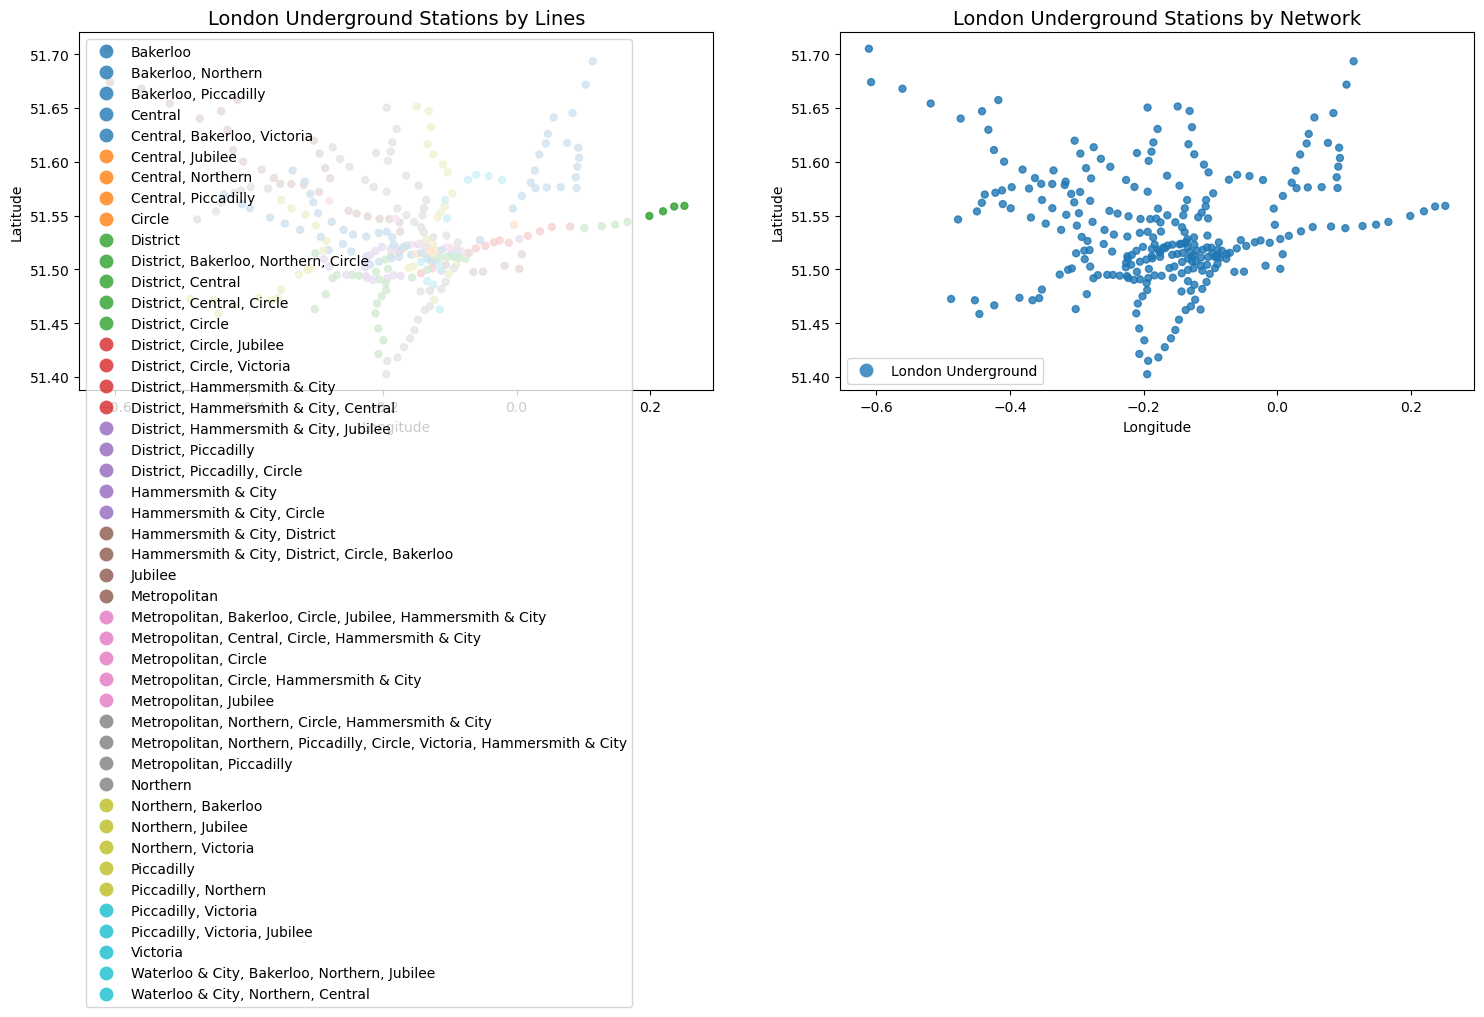

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
# --- Plot by LINES ---
stations.plot(
    ax=axes[0],
    column="LINES",
    categorical=True,
    legend=True,
    markersize=25,
    alpha=0.8,
)
axes[0].set_title("London Underground Stations by Lines", fontsize=14)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
# --- Plot by NETWORK ---
stations.plot(
    ax=axes[1],
    column="NETWORK",
    categorical=True,
    legend=True,
    markersize=25,
    alpha=0.8,
)
axes[1].set_title("London Underground Stations by Network", fontsize=14)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

In [ ]:
from matplotlib.lines import Line2D

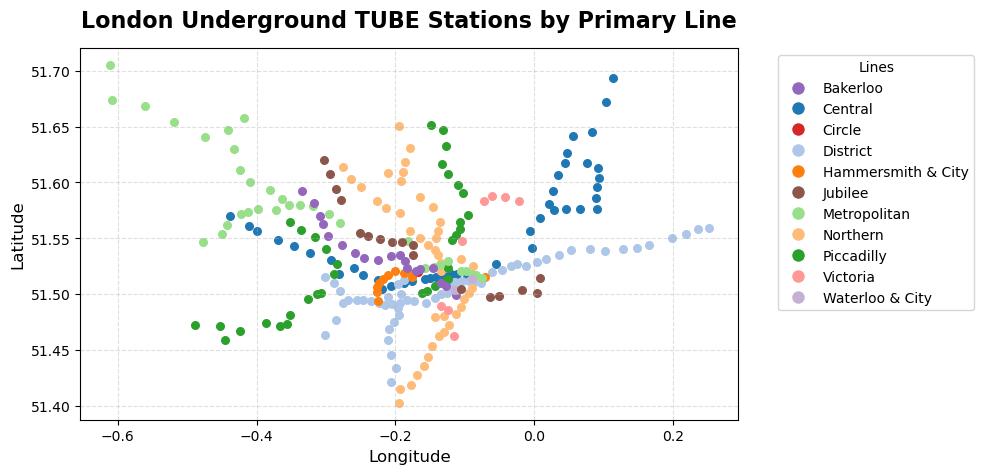

In [ ]:

fig, ax = plt.subplots(figsize=(10, 10))

# Only keep the primary line name (if multiple listed)
stations["PrimaryLine"] = stations["LINES"].str.split(",").str[0].str.strip()

# --- Plot stations by primary line ---
lines = stations["PrimaryLine"].unique()
colors = plt.cm.tab20.colors  # nice balanced color palette
color_map = {line: colors[i % len(colors)] for i, line in enumerate(lines)}

for line in lines:
    subset = stations[stations["PrimaryLine"] == line]
    subset.plot(ax=ax, color=color_map[line], markersize=30, label=line)


ax.set_title("London Underground TUBE Stations by Primary Line", fontsize=16, weight='bold', pad=15)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

legend_elements = [Line2D([0], [0], marker='o', color='w',
                          label=line, markerfacecolor=color_map[line], markersize=10)
                   for line in sorted(lines)]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1), title="Lines")


plt.tight_layout()
plt.show()

## MAP BASED ON ACCESSIBILITY

In [ ]:
print(stations["ACCESSIBIL"].unique())

['Not Accessible' 'Partially Accessible - Interchange Only'
 'Partially Accessible' 'Fully Accessible' None]


In [ ]:
#group ACCESSIBIL categories
def categorize_accessibility(value):
    if value is None:
        return "Unknown"
    value = value.lower()
    if "not" in value:
        return "Not Accessible"
    elif "partial" in value:
        return "Partially Accessible"
    elif "fully" in value:
        return "Fully Accessible"
    else:
        return "Unknown"

stations["Access_Category"] = stations["ACCESSIBIL"].apply(categorize_accessibility)

In [ ]:
not_accessible = stations[stations["Access_Category"] == "Not Accessible"]
partial_accessible = stations[stations["Access_Category"] == "Partially Accessible"]
fully_accessible = stations[stations["Access_Category"] == "Fully Accessible"]

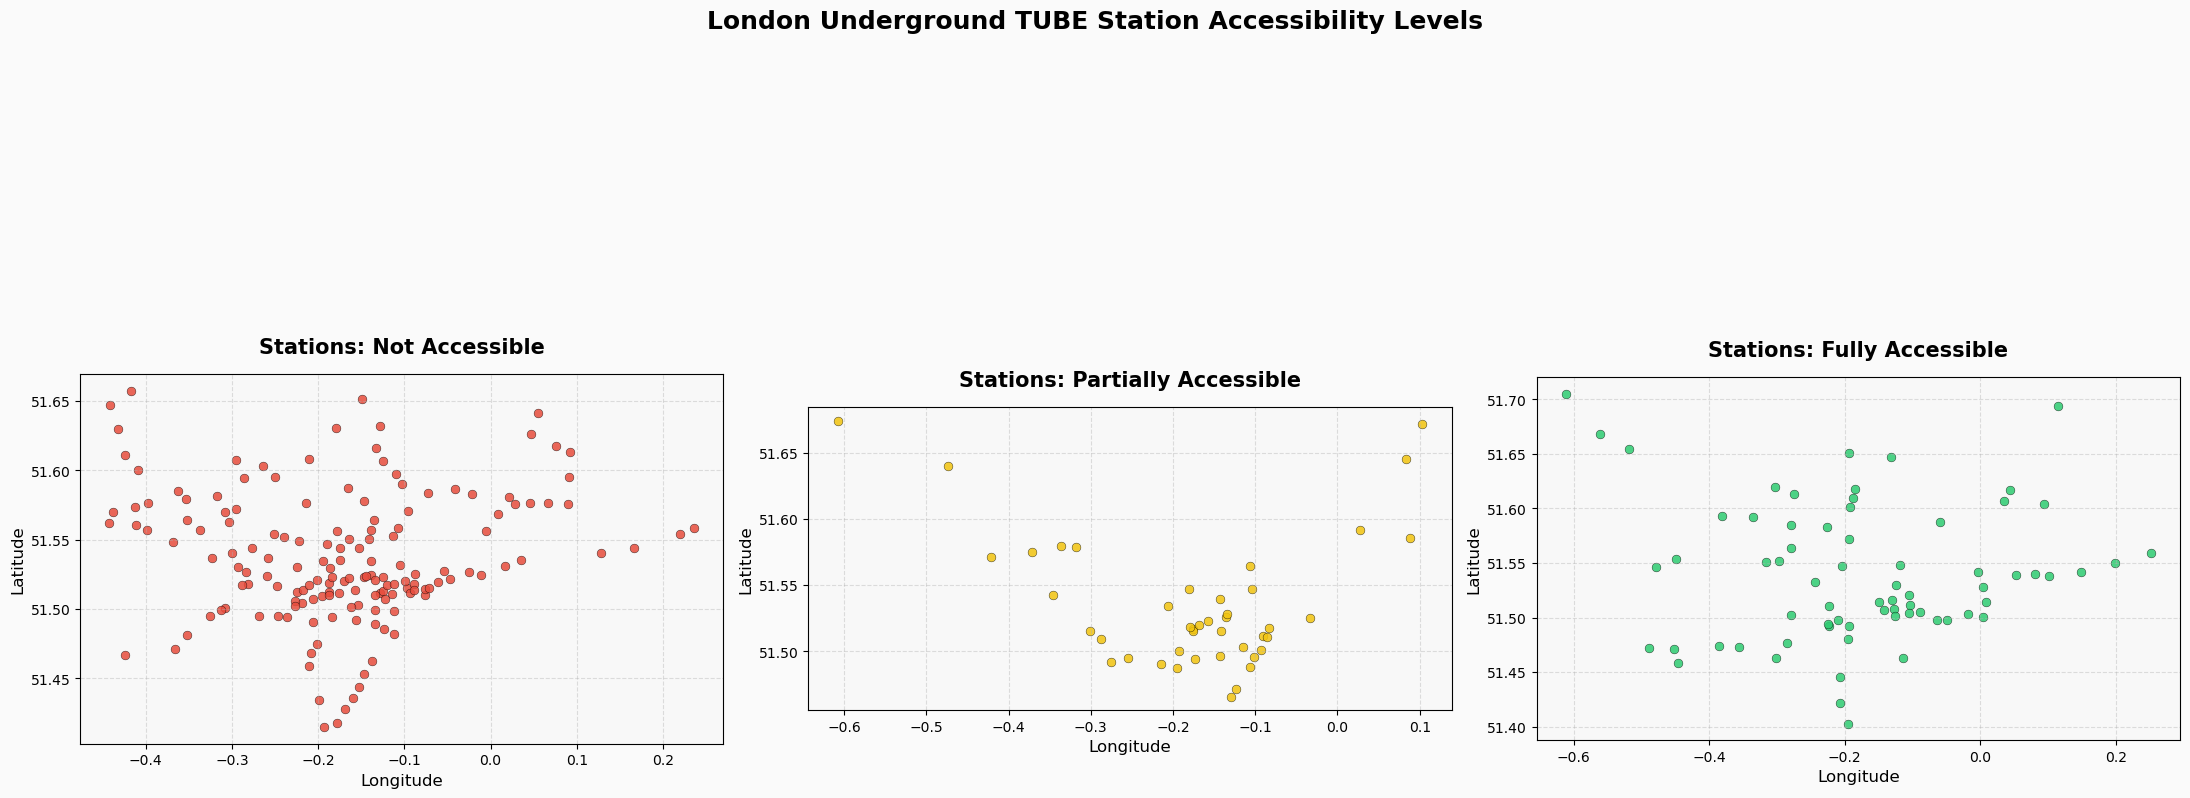

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 10), facecolor="#fafafa")

# --- Plot 1: Not Accessible ---
not_accessible.plot(
    ax=axes[0],
    color="#e74c3c",  # red
    markersize=40,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.3
)
axes[0].set_title("Stations: Not Accessible", fontsize=15, weight='bold', pad=15)
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].set_facecolor("#f8f8f8")

# --- Plot 2: Partially Accessible ---
partial_accessible.plot(
    ax=axes[1],
    color="#f1c40f",  # yellow
    markersize=40,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.3
)
axes[1].set_title("Stations: Partially Accessible", fontsize=15, weight='bold', pad=15)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].set_facecolor("#f8f8f8")

# --- Plot 3: Fully Accessible ---
fully_accessible.plot(
    ax=axes[2],
    color="#2ecc71",  # green
    markersize=40,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.3
)
axes[2].set_title("Stations: Fully Accessible", fontsize=15, weight='bold', pad=15)
axes[2].grid(True, linestyle="--", alpha=0.4)
axes[2].set_facecolor("#f8f8f8")


for ax in axes:
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)

plt.suptitle("London Underground TUBE Station Accessibility Levels", fontsize=18, weight='bold', y=1.03)
plt.tight_layout()
plt.show()

## MAP BASED ON TIME OF OPERATION (NGHT VS NO NIGHT OPERATION)

In [ ]:
print(stations["NIGHT_TUBE"].unique())

['Yes' 'No']


In [ ]:
night_yes = stations[stations["NIGHT_TUBE"].str.lower() == "yes"]
night_no = stations[stations["NIGHT_TUBE"].str.lower() == "no"]

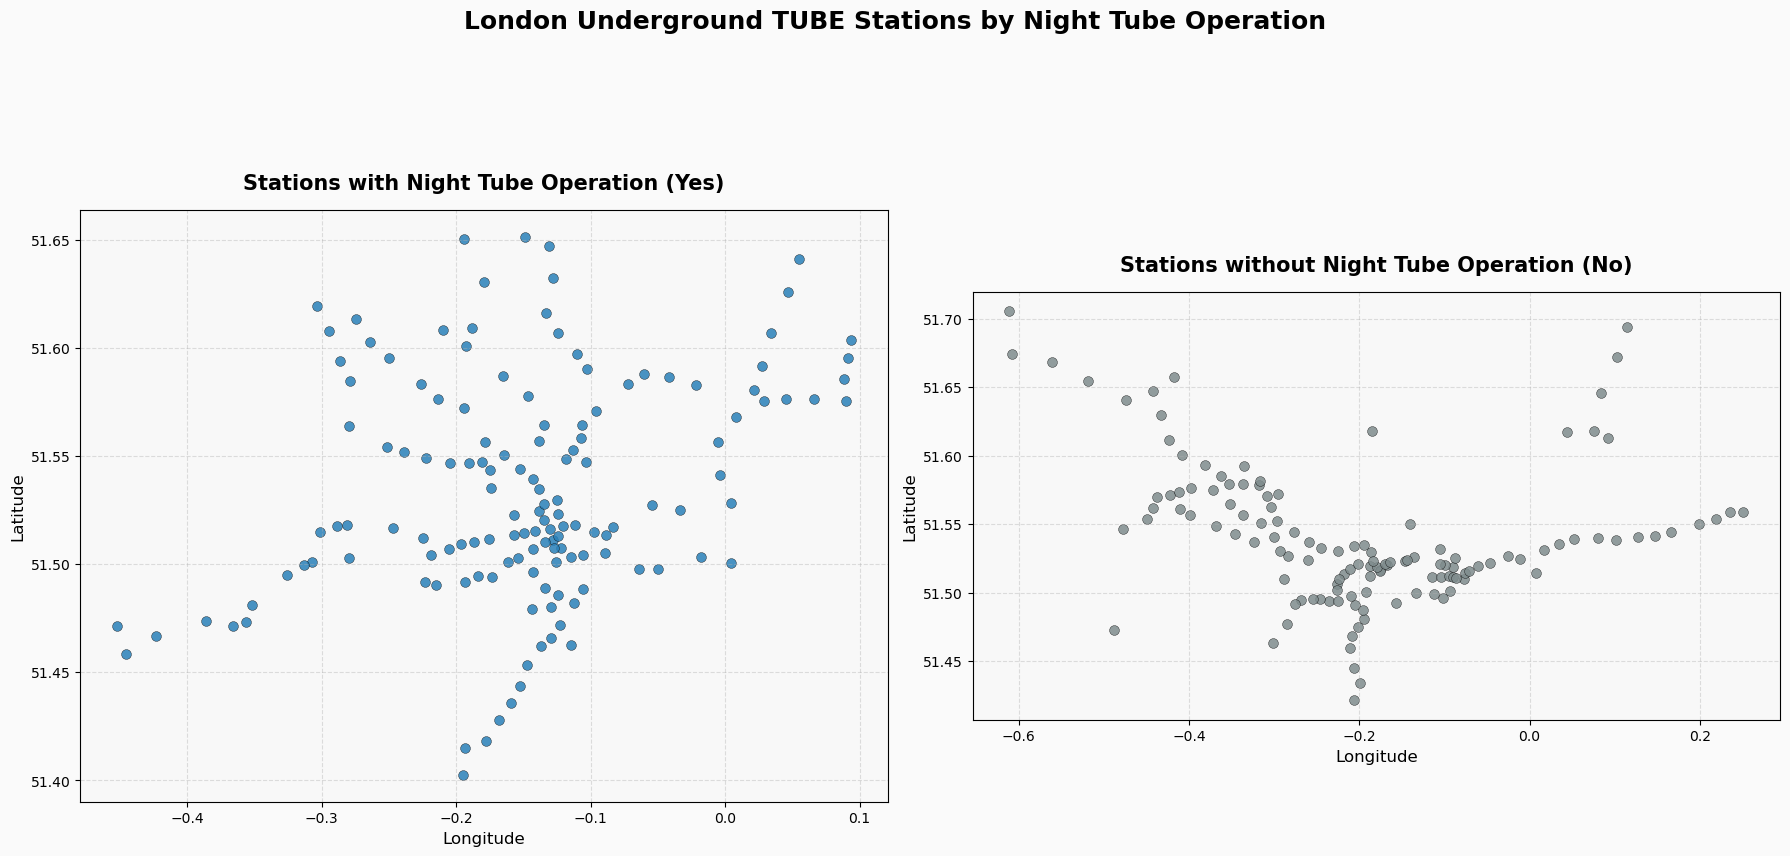

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9), facecolor="#fafafa")

# --- Plot 1: Night Tube = Yes ---
night_yes.plot(
    ax=axes[0],
    color="#2980b9",  # blue
    markersize=50,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.3
)
axes[0].set_title("Stations with Night Tube Operation (Yes)", fontsize=15, weight="bold", pad=15)
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].set_facecolor("#f8f8f8")

# --- Plot 2: Night Tube = No ---
night_no.plot(
    ax=axes[1],
    color="#7f8c8d",  # grey
    markersize=50,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.3
)
axes[1].set_title("Stations without Night Tube Operation (No)", fontsize=15, weight="bold", pad=15)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].set_facecolor("#f8f8f8")


for ax in axes:
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)

plt.suptitle("London Underground TUBE Stations by Night Tube Operation", fontsize=18, weight="bold", y=1.03)
plt.tight_layout()
plt.show()